Saving Experiments_5_7_ML_Dataset.csv to Experiments_5_7_ML_Dataset (1).csv
Dataset Shape: (500, 9)


,StudyHours,Attendance,AssignmentsCompleted,PreviousScore,SleepHours,InternetUsageHours,PracticeTests,FinalScore,PlacementStatus
0,4.37,86.42,9,51.86,7.18,4.17,0,85.58,1
1,9.56,79.12,4,76.24,7.93,3.51,1,101.26,1
2,7.59,68.93,9,61.66,4.59,7.95,10,101.35,1
3,6.39,91.62,6,75.82,6.05,7.10,8,109.08,1
4,2.40,85.81,2,45.86,8.20,5.18,8,67.22,0



Class Distribution:
PerformanceClass
2    270
1    157
0     73
Name: count, dtype: int64

Training data: (400, 7)
Testing data : (100, 7)

Model training completed!

Multinomial Logistic Regression Accuracy: 0.83

Confusion Matrix:
[[ 9  6  0]
 [ 1 23  7]
 [ 0  3 51]]

Classification Report:
              precision    recall  f1-score   support

         Low       0.90      0.60      0.72        15
      Medium       0.72      0.74      0.73        31
        High       0.88      0.94      0.91        54

    accuracy                           0.83       100
   macro avg       0.83      0.76      0.79       100
weighted avg       0.83      0.83      0.83       100



/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


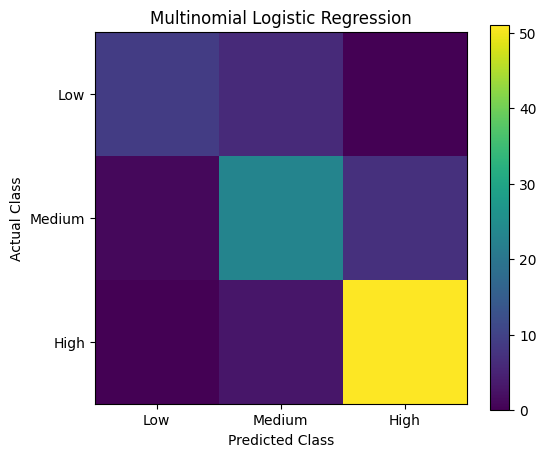

In [4]:
# ============================================================
# EXPERIMENT: LOGISTIC REGRESSION
# MULTINOMIAL CLASSIFICATION
# ============================================================

# 1. Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

# ============================================================
# 2. Upload CSV
# ============================================================

uploaded = files.upload()

df = pd.read_csv("Experiments_5_7_ML_Dataset.csv")

print("Dataset Shape:", df.shape)

display(df.head())

# ============================================================
# 3. Create 3 Classes
# ============================================================

df["PerformanceClass"] = pd.cut(
    df["FinalScore"],
    bins=[-np.inf, 75, 90, np.inf],
    labels=[0, 1, 2]
).astype(int)

print("\nClass Distribution:")
print(df["PerformanceClass"].value_counts())

# ============================================================
# 4. Select Features and Target
# ============================================================

X = df.drop(
    columns=[
        "FinalScore",
        "PlacementStatus",
        "PerformanceClass"
    ]
)

y = df["PerformanceClass"]

# ============================================================
# 5. Split Dataset
# ============================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("\nTraining data:", X_train.shape)
print("Testing data :", X_test.shape)

# ============================================================
# 6. Standardize Features
# ============================================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ============================================================
# 7. Create Multinomial Logistic Regression
# ============================================================

model = LogisticRegression(
    multi_class="multinomial",
    max_iter=1000,
    random_state=42
)

# ============================================================
# 8. Train Model
# ============================================================

model.fit(X_train_scaled, y_train)

print("\nModel training completed!")

# ============================================================
# 9. Prediction
# ============================================================

y_pred = model.predict(X_test_scaled)

# ============================================================
# 10. Accuracy
# ============================================================

accuracy = accuracy_score(y_test, y_pred)

print(
    "\nMultinomial Logistic Regression Accuracy:",
    round(accuracy, 4)
)

# ============================================================
# 11. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# ============================================================
# 12. Classification Report
# ============================================================

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Low",
            "Medium",
            "High"
        ]
    )
)

# ============================================================
# 13. Plot Confusion Matrix
# ============================================================

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Multinomial Logistic Regression")

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")

plt.colorbar()

plt.xticks(
    [0, 1, 2],
    ["Low", "Medium", "High"]
)

plt.yticks(
    [0, 1, 2],
    ["Low", "Medium", "High"]
)

plt.show()